# Tracking Scripts for beads and dots

This notebook is designed to track beads and dots and get the average mean squared displacement to compare tethered vs. untethered

First we load in the data. This is desigend for the andor SIF files and so for other files, make your own loader and load the data in and name it appropriately. Here the data is loaded in the image_data variable. The values in the array are the intensities of the pixels where the first index is the frame number, the second index is the y axis, and the third index is the x axis

{'SifVersion': 65567, 'ExperimentTime': 1737633023, 'DetectorTemperature': -999.0, 'ExposureTime': 0.1, 'CycleTime': 0.39261, 'AccumulatedCycleTime': 0.39261, 'AccumulatedCycles': 1, 'StackCycleTime': 0.39261, 'PixelReadoutTime': 1e-06, 'GainDAC': 100.0, 'GateWidth': 0.0, 'GratingBlaze': 3.3e-06, 'DetectorType': 'DU897_BV', 'DetectorDimensions': (512, 512), 'OriginalFilename': 'C:\\Users\\Lab\\Desktop\\DATA\\Tomny\\2025\\2025_01_22\\beads\\1_free&tether&stuck.sif', 'ShutterTime': (0.0, 0.0), 'spectrograph': 'Spectrograph_None999', 'GateGain': 0.0, 'GateDelay': 0.0, 'SifCalbVersion': 65540, 'RamanExWavelength': 422.0, 'FrameAxis': 'Pixel number', 'DataType': 'Counts', 'ImageAxis': 'Pixel number', 'NumberOfFrames': 100, 'NumberOfSubImages': 1, 'TotalLength': 26214400, 'ImageLength': 262144, 'xbin': 1, 'ybin': 1, 'size': (512, 512), 'offset': 3936}
0.1
0.39261
100


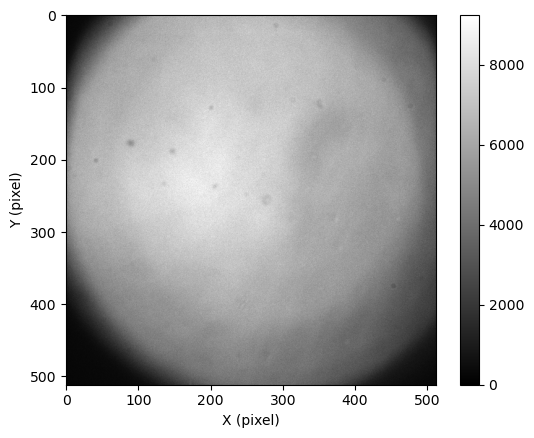

In [ ]:
import sif_parser
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Open the SIF file. 512x512 is pixel size of the camera
filename = '/Users/tommtommbom/Desktop/qdrepos/andor_data/2025_02_05/dna10x_stuck.sif'
data = sif_parser.xr_open(filename)
print(data.attrs)
print(data.ExposureTime) # exposure time of when shutter opens to close. Check docs on andor for exact time
print(data.CycleTime) #time when shutter opens to next time when shutter OPENS. Check andor docs to see exact time
print(data.NumberOfFrames) # obvious 
# Access the data array. # axis 0 is frame, axis 1 is the y axis in the image and axis 2 is the x axis in the image
image_data = data.values

# getting rid of the dead pixels of the line for the andor camera
# Set the selected region to the average of the 10 pixels around it
# would be better to bkg subtract but the pixels change in intensity depending on laser power so would have to do this for every power
for i in range(image_data.shape[0]):
    for j in range(290, image_data.shape[1]):
        for k in range(171, 173):
            image_data[i, j, k] = np.mean(image_data[i, max(0, j-10):min(image_data.shape[1], j+10), max(0, k-10):min(image_data.shape[2], k+10)])

# Plot the image
framenum = 0
plt.imshow(image_data[framenum], cmap="gray", vmin=0)
plt.xlabel('X (pixel)')
plt.ylabel('Y (pixel)')
plt.colorbar()
plt.show()

Basically following a tutorial online for trackpy: https://soft-matter.github.io/trackpy/dev/tutorial/walkthrough.html
This site might also be helpful for tracking particles in brightfield (beads) https://soft-matter.github.io/trackpy/dev/tutorial/brightfield.html. For dots, the radius should be r+4, minmass = 1250, threshold = 20, percentile = 90 were good values. This will all change depending on what and how bright the feature is so you should make sure that it locates the feature correctly for different frames.

Using a radius of 5 px


<Axes: >

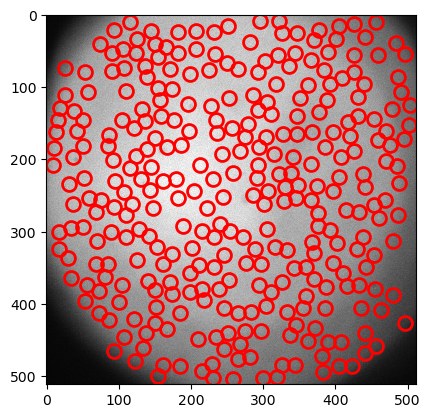

In [81]:
# this is for qds, and will try to optimize for tethered beads
import pandas as pd
from pandas import DataFrame, Series  # for convenience
import trackpy as tp

# Finding the radius of the feature
micron_per_pixel = 20/80.056 # for andor camera
feature_diameter = 2 # um. good to err on large side for this package.
radius = int(np.round(feature_diameter/2.0/micron_per_pixel))
if radius % 2 ==  0:
    radius += 1
print('Using a radius of {:d} px'.format(radius))

# PARAMETERS TO BE CHANGED
frames = image_data
frame_num = 20
r = radius + 10 # we use a slightly larger radius for error in case it's larger (clumps of qds)
minmass = 1250 # minimum integrated brightness of feature, https://soft-matter.github.io/trackpy/dev/generated/trackpy.locate.html 
threshold = 20 # threshold could be useful which eliminates noise below value. might want to bkg subrtract first
percentile = 90 # choose >90th brightest percentile of image for feature selection
plt.figure()
f_locate = tp.locate(frames[frame_num], r, minmass=minmass, threshold=threshold, percentile = percentile) 
tp.annotate(f_locate, frames[frame_num], plot_style={'markersize': radius*2}, ax=plt.gca(), imshow_style={'cmap':'gray', 'vmin':0})

You should see a red circle around the features of interest for multiple frames indicating that the program can locate your dot

Now we locate the features for all frames and link the tracking to plot trajectories. The link function takes two parameters. The first number is how much the particle can travel between frames and the 2nd is how many frames it can be missing. since can blink and go out of focus, generous estimate of 10. Then filter out trajectories that last at least n frames (10 is a good number). Plot the trajectories and should look and see if it makes sense i.e. it is tracking correctly

Before: 1
After: 1


/usr/local/anaconda3/envs/qdmodel/lib/python3.12/site-packages/trackpy/plots.py:356: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  coords = unstacked.fillna(method='backfill').stack().loc[first_frame]
/usr/local/anaconda3/envs/qdmodel/lib/python3.12/site-packages/trackpy/plots.py:356: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  coords = unstacked.fillna(method='backfill').stack().loc[first_frame]


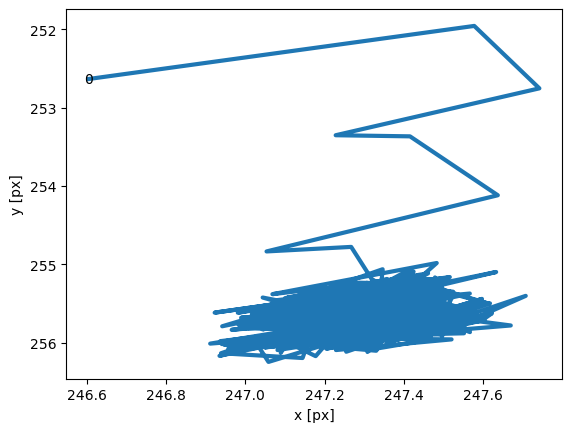

<Axes: xlabel='x [px]', ylabel='y [px]'>

In [78]:
# find the features for all frames 
features = tp.batch(frames, r, minmass=minmass, threshold=threshold, percentile = percentile)
t = tp.link(features, 50, memory=10)
# the value keeps only trajectories that last at least n frames
t1 = tp.filter_stubs(t, 10)
# Compare the number of particles in the unfiltered and filtered data.
print('Before:', t['particle'].nunique())
print('After:', t1['particle'].nunique())
plt.figure()
tp.plot_traj(t1, plot_style={'linewidth':3}, label=True)  


Now can compute the mean squared displacement for the particles

                     0
lag time [s]          
0.30261       0.003212
0.60522       0.003361
0.90783       0.003904
1.21044       0.004285
1.51305       0.004783
...                ...
29.05056      0.007604
29.35317      0.007466
29.65578      0.007455
29.95839      0.007432
30.26100      0.007394

[100 rows x 1 columns]


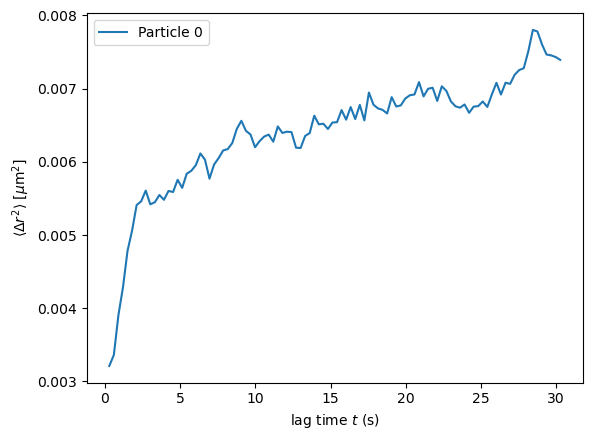

In [79]:
im = tp.imsd(t1, micron_per_pixel, 1/data.CycleTime)  # microns per pixel = 100/285., frames per second = 24
fig, ax = plt.subplots()
for particle in im.columns:
       if particle != 10:
              ax.plot(im.index, im[particle], label=f'Particle {particle}')  # black lines, semitransparent
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
          xlabel='lag time $t$ (s)')
ax.legend()
print(im)
# ax.set_xscale('log')
# ax.set_yscale('log')

# Tracking for Beads

Essentially like the dots but b/c the beads are brightfield, have to look for dark features and change the params

{'SifVersion': 65567, 'ExperimentTime': 1737633023, 'DetectorTemperature': -999.0, 'ExposureTime': 0.1, 'CycleTime': 0.39261, 'AccumulatedCycleTime': 0.39261, 'AccumulatedCycles': 1, 'StackCycleTime': 0.39261, 'PixelReadoutTime': 1e-06, 'GainDAC': 100.0, 'GateWidth': 0.0, 'GratingBlaze': 3.3e-06, 'DetectorType': 'DU897_BV', 'DetectorDimensions': (512, 512), 'OriginalFilename': 'C:\\Users\\Lab\\Desktop\\DATA\\Tomny\\2025\\2025_01_22\\beads\\1_free&tether&stuck.sif', 'ShutterTime': (0.0, 0.0), 'spectrograph': 'Spectrograph_None999', 'GateGain': 0.0, 'GateDelay': 0.0, 'SifCalbVersion': 65540, 'RamanExWavelength': 422.0, 'FrameAxis': 'Pixel number', 'DataType': 'Counts', 'ImageAxis': 'Pixel number', 'NumberOfFrames': 100, 'NumberOfSubImages': 1, 'TotalLength': 26214400, 'ImageLength': 262144, 'xbin': 1, 'ybin': 1, 'size': (512, 512), 'offset': 3936}
0.1
0.39261
100


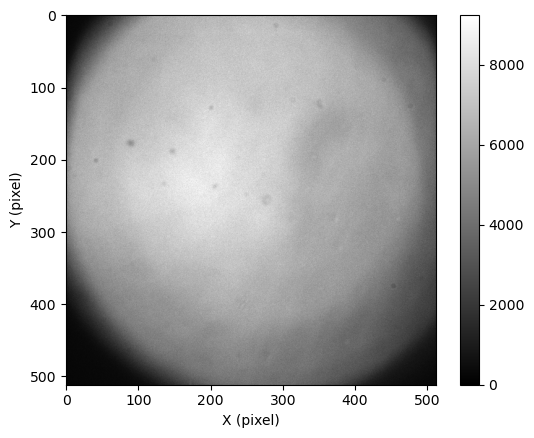

In [82]:
# Open the SIF file. 512x512 is pixel size of the camera
filename = '/Users/tommtommbom/Desktop/qdrepos/andor_data/2025_01_22/beads/1_free&tether&stuck.sif'
data = sif_parser.xr_open(filename)
print(data.attrs)
print(data.ExposureTime) # exposure time of when shutter opens to close. Check docs on andor for exact time
print(data.CycleTime) #time when shutter opens to next time when shutter OPENS. Check andor docs to see exact time
print(data.NumberOfFrames) # obvious 
# Access the data array. # axis 0 is frame, axis 1 is the y axis in the image and axis 2 is the x axis in the image
image_data = data.values

# getting rid of the dead pixels of the line for the andor camera
# Set the selected region to the average of the 10 pixels around it
# would be better to bkg subtract but the pixels change in intensity depending on laser power so would have to do this for every power
for i in range(image_data.shape[0]):
    for j in range(290, image_data.shape[1]):
        for k in range(171, 173):
            image_data[i, j, k] = np.mean(image_data[i, max(0, j-10):min(image_data.shape[1], j+10), max(0, k-10):min(image_data.shape[2], k+10)])

# Plot the image
framenum = 0
plt.imshow(image_data[framenum], cmap="gray", vmin=0)
plt.xlabel('X (pixel)')
plt.ylabel('Y (pixel)')
plt.colorbar()
plt.show()


Using a radius of 5 px


<Axes: >

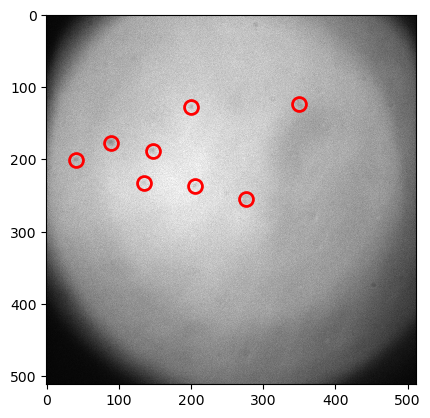

In [98]:
# Finding the radius of the feature
micron_per_pixel = 20/80.056 # for andor camera
feature_diameter = 2 # um. good to err on large side for this package.
radius = int(np.round(feature_diameter/2.0/micron_per_pixel))
if radius % 2 ==  0:
    radius += 1
print('Using a radius of {:d} px'.format(radius))

# PARAMETERS TO BE CHANGED
frames = image_data
frame_num = 0
r = radius + 30 # we use a slightly larger radius for error in case it's larger (clumps of qds)
minmass = 250 # minimum integrated brightness of feature, https://soft-matter.github.io/trackpy/dev/generated/trackpy.locate.html 
threshold = 300 # threshold could be useful which eliminates noise below value. might want to bkg subrtract first
percentile = 50 # choose >90th brightest percentile of image for feature selection
plt.figure()
f_locate = tp.locate(frames[frame_num], r, minmass=minmass, threshold=threshold, percentile = percentile, invert=True) 
tp.annotate(f_locate, frames[frame_num], plot_style={'markersize': radius*2}, ax=plt.gca(), imshow_style={'cmap':'gray', 'vmin':0})

Before: 68
After: 7


/usr/local/anaconda3/envs/qdmodel/lib/python3.12/site-packages/trackpy/plots.py:356: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  coords = unstacked.fillna(method='backfill').stack().loc[first_frame]
/usr/local/anaconda3/envs/qdmodel/lib/python3.12/site-packages/trackpy/plots.py:356: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  coords = unstacked.fillna(method='backfill').stack().loc[first_frame]


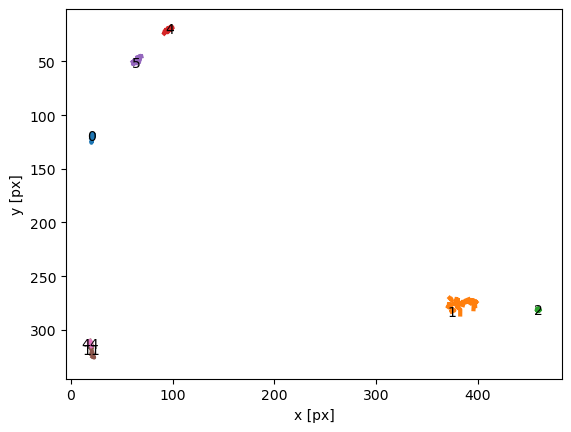

<Axes: xlabel='x [px]', ylabel='y [px]'>

In [99]:
# find the features for all frames 
features = tp.batch(frames, r, minmass=minmass, threshold=threshold, percentile = percentile)
t = tp.link(features, 10, memory=5)
# the value keeps only trajectories that last at least n frames
t1 = tp.filter_stubs(t, 10)
# Compare the number of particles in the unfiltered and filtered data.
print('Before:', t['particle'].nunique())
print('After:', t1['particle'].nunique())
plt.figure()
tp.plot_traj(t1, plot_style={'linewidth':3}, label=True)  

                    0          1         2         4         5         11  \
lag time [s]                                                                
0.39261       0.176464   0.499882  0.050342  0.552366  0.949348  1.557424   
0.78522       0.078555   0.913122  0.046586  0.682299  0.530176  0.425311   
1.17783       0.141022   1.094254  0.048204  0.601251  1.548749  0.990268   
1.57044       0.178471   1.119447  0.032714  0.693122  1.511882  2.770055   
1.96305       0.129978   1.539865  0.043147  0.542808  1.094540  0.887869   
...                ...        ...       ...       ...       ...       ...   
37.29795      0.151486  18.024200  0.034485  0.732076  0.000000       NaN   
37.69056      0.238434  19.084680  0.035776  0.326461  0.859121       NaN   
38.08317      0.094208  25.501440  0.053883  2.107017  0.840057       NaN   
38.47578      0.061333        NaN  0.000000  1.399600  0.581840       NaN   
38.86839      0.010184        NaN  0.102385       NaN       NaN       NaN   

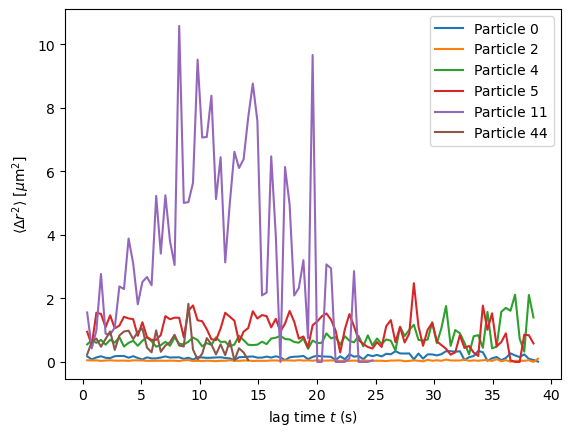

In [106]:
im = tp.imsd(t1, micron_per_pixel, 1/data.CycleTime)  # microns per pixel = 100/285., frames per second = 24
fig, ax = plt.subplots()
for particle in im.columns:
       if particle != 1:
              ax.plot(im.index, im[particle], label=f'Particle {particle}')  # black lines, semitransparent
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
          xlabel='lag time $t$ (s)')
ax.legend()
print(im)
# ax.set_xscale('log')
# ax.set_yscale('log')

# The rest of this notebook is scratchwork for eliminating overall drift

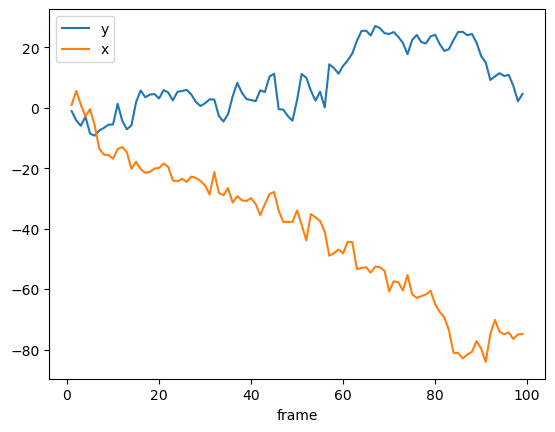

In [34]:
d = tp.compute_drift(t1)
d.plot()
plt.show()

/usr/local/anaconda3/envs/qdmodel/lib/python3.12/site-packages/trackpy/plots.py:356: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  coords = unstacked.fillna(method='backfill').stack().loc[first_frame]
/usr/local/anaconda3/envs/qdmodel/lib/python3.12/site-packages/trackpy/plots.py:356: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  coords = unstacked.fillna(method='backfill').stack().loc[first_frame]


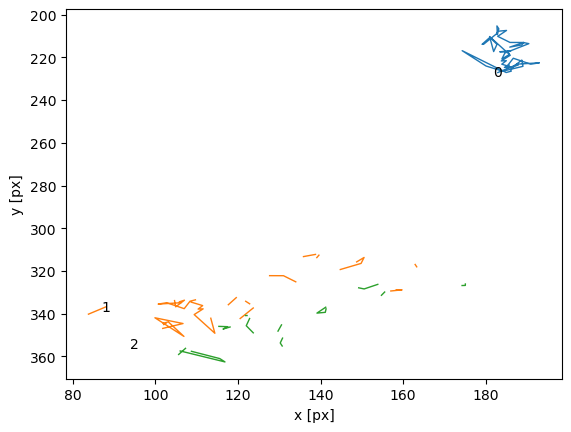

In [35]:
tm = tp.subtract_drift(t1.copy(), d)
tm.index = tm.index.droplevel(1)
ax = tp.plot_traj(tm, label=True)
plt.show()

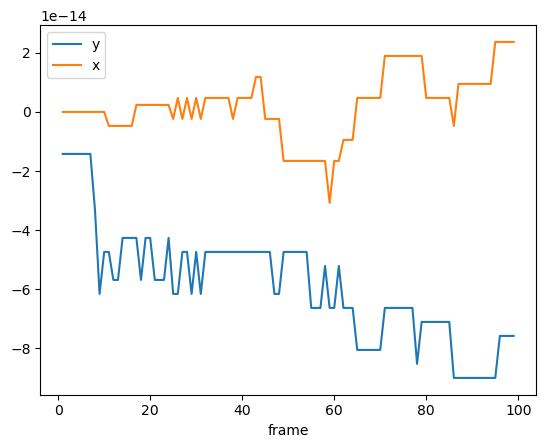

In [36]:
d = tp.compute_drift(tm)
d.plot()
plt.show()


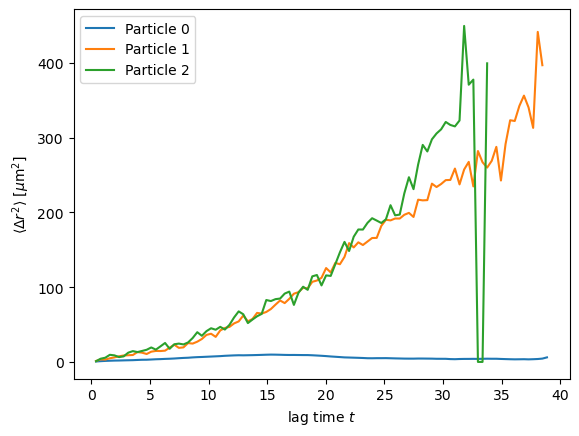

In [37]:
im = tp.imsd(tm, micron_per_pixel, 1/data.CycleTime)  # microns per pixel = 100/285., frames per second = 24
fig, ax = plt.subplots()
for particle in im.columns:
       ax.plot(im.index, im[particle], label=f'Particle {particle}')  # black lines, semitransparent
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
          xlabel='lag time $t$')
ax.legend()
# ax.set_xscale('log')
# ax.set_yscale('log')